In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Train.csv')

In [3]:
df.shape

(8068, 11)

In [4]:
df

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [6]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [7]:
df.describe(include='O')

,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1,Segmentation
count,8068,7928,7990,7944,8068,7992,8068
unique,2,2,2,9,3,7,4
top,Male,Yes,Yes,Artist,Low,Cat_6,D
freq,4417,4643,4968,2516,4878,5238,2268


In [8]:
df.duplicated().sum()

0

# EDA

In [10]:
corr_matrix = df.corr(numeric_only=True)

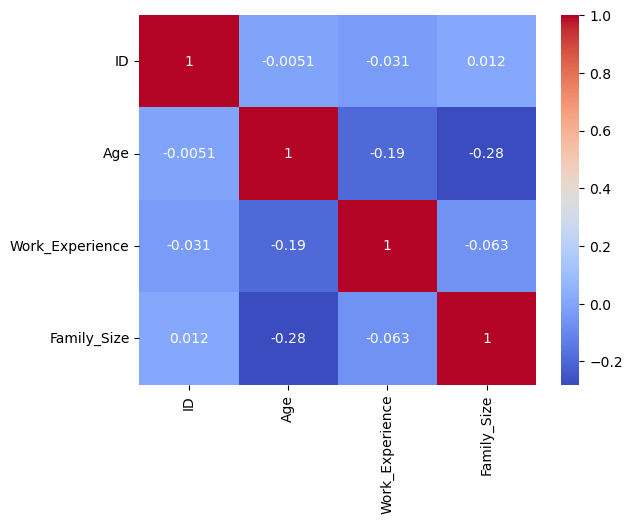

In [11]:
sns.heatmap(data=corr_matrix, annot=True, cmap ='coolwarm');

In [12]:
df['Segmentation'].value_counts()

Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64

In [13]:
df['Profession'].value_counts()

Profession
Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: count, dtype: int64

In [14]:
df['Ever_Married'].value_counts()

Ever_Married
Yes    4643
No     3285
Name: count, dtype: int64

In [15]:
df['Var_1'].value_counts()

Var_1
Cat_6    5238
Cat_4    1089
Cat_3     822
Cat_2     422
Cat_7     203
Cat_1     133
Cat_5      85
Name: count, dtype: int64

In [16]:
df['Spending_Score'].value_counts()

Spending_Score
Low        4878
Average    1974
High       1216
Name: count, dtype: int64

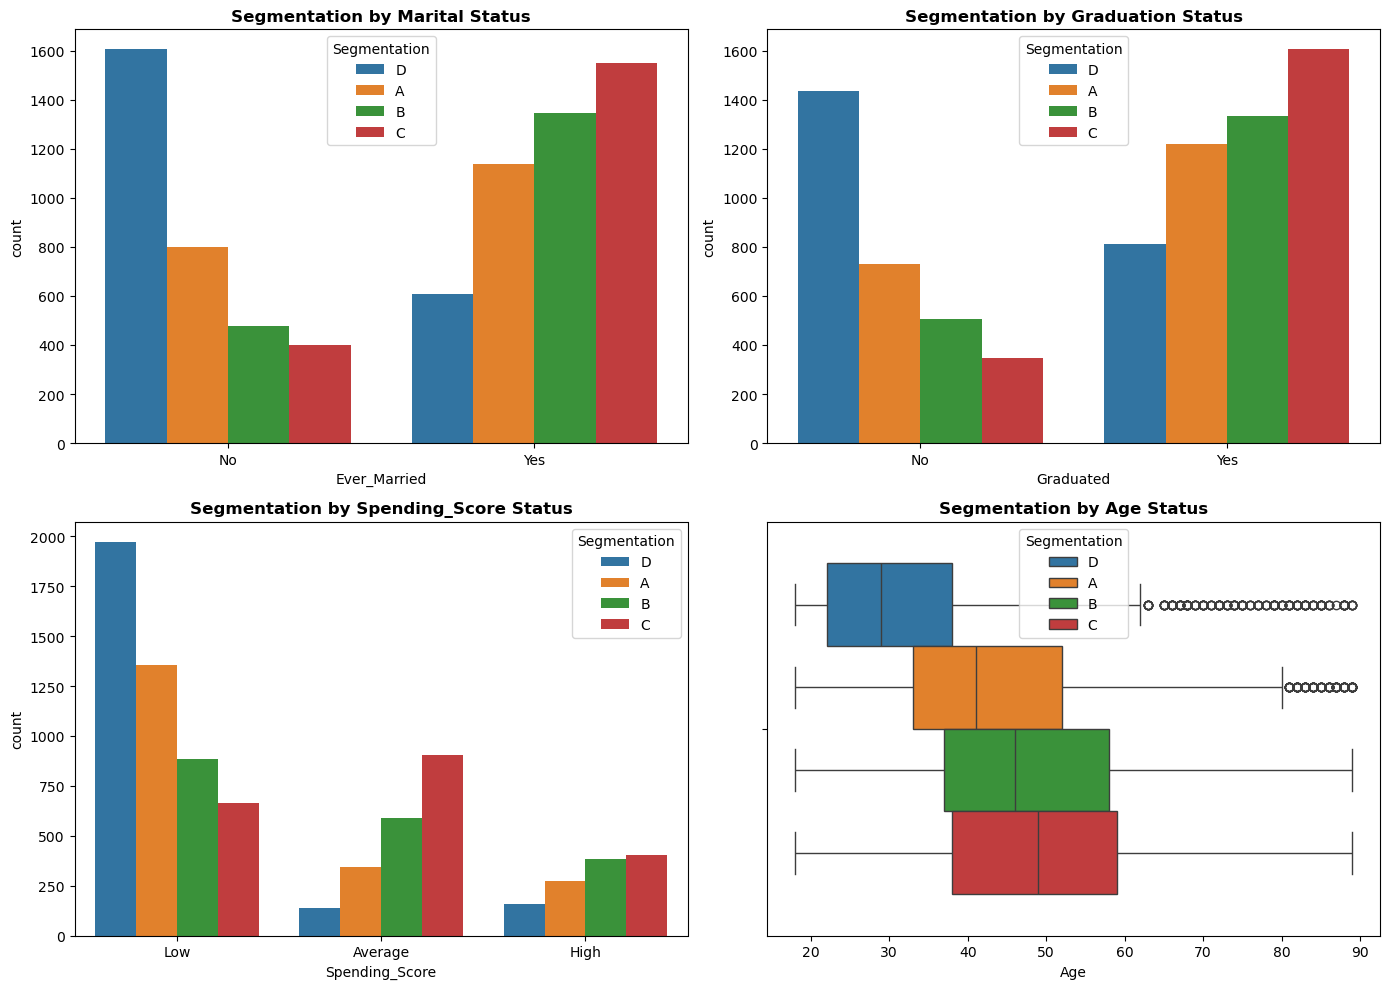

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
sns.countplot(
    x=df['Ever_Married'], 
    hue=df['Segmentation'], 
    ax=axes[0] 
)
axes[0].set_title('Segmentation by Marital Status', fontsize=12, fontweight='bold')

sns.countplot(
    x=df['Graduated'], 
    hue=df['Segmentation'], 
    ax=axes[1]
)
axes[1].set_title('Segmentation by Graduation Status', fontsize=12, fontweight='bold')

sns.countplot(
    x=df['Spending_Score'], 
    hue=df['Segmentation'], 
    ax=axes[2]
)
axes[2].set_title('Segmentation by Spending_Score Status', fontsize=12, fontweight='bold')

sns.boxplot(
    x=df['Age'], 
    hue=df['Segmentation'], 
    ax=axes[3]
)
axes[3].set_title('Segmentation by Age Status', fontsize=12, fontweight='bold')

plt.tight_layout()

plt.show();

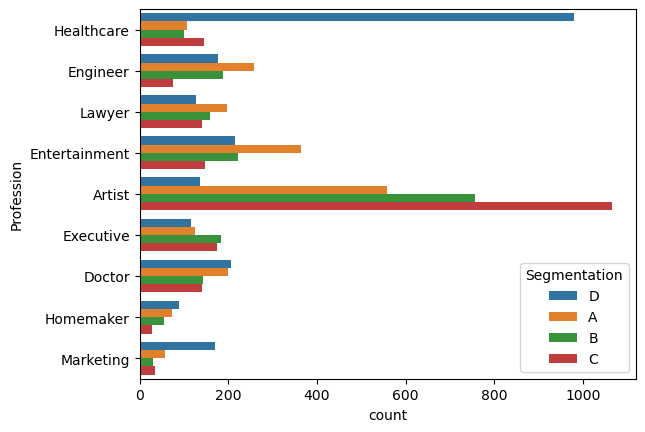

In [18]:
sns.countplot(y = df['Profession'] , hue=df['Segmentation'] );

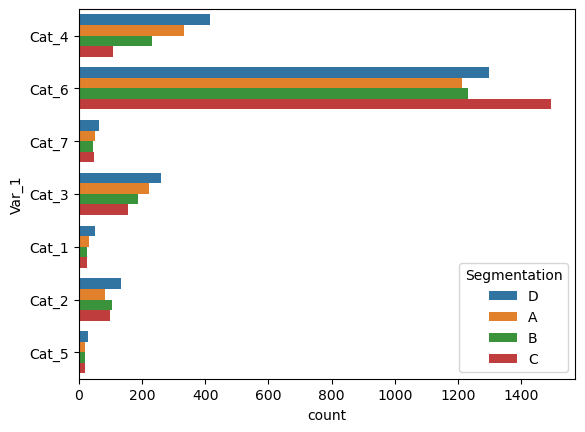

In [19]:
sns.countplot(y = df['Var_1'] , hue=df['Segmentation'] );

In [20]:
(df['Age'].groupby(df['Profession']).median()).sort_values(ascending = False)

Profession
Lawyer           77.0
Executive        50.0
Artist           45.0
Entertainment    41.0
Engineer         40.0
Doctor           35.0
Homemaker        35.0
Marketing        33.0
Healthcare       26.0
Name: Age, dtype: float64

In [21]:
df.groupby(['Spending_Score'])['Age'].median().sort_values(ascending=False)

Spending_Score
High       57.5
Average    46.5
Low        35.0
Name: Age, dtype: float64

In [22]:
df.groupby(['Segmentation','Spending_Score'])['Age'].median().sort_values(ascending=False)

Segmentation  Spending_Score
C             High              60.0
A             High              59.0
B             High              58.0
C             Average           50.0
B             Average           46.0
              Low               42.0
D             High              42.0
A             Average           40.0
              Low               40.0
C             Low               38.0
D             Average           36.0
              Low               28.0
Name: Age, dtype: float64

# Preprocessing Pipeline

In [24]:
df.columns

Index(['ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1',
       'Segmentation'],
      dtype='object')

In [25]:
df = df.drop(columns='ID')

In [26]:
df.shape

(8068, 10)

In [27]:
df['Segmentation'].isna().sum()

0

In [28]:
X_train = df.drop(columns='Segmentation')
Y_train = df['Segmentation']

In [29]:
X_train.shape , Y_train.shape

((8068, 9), (8068,))

In [30]:
X_train.describe()

,Age,Work_Experience,Family_Size
count,8068.000000,7239.000000,7733.000000
mean,43.466906,2.641663,2.850123
std,16.711696,3.406763,1.531413
min,18.000000,0.000000,1.000000
25%,30.000000,0.000000,2.000000
50%,40.000000,1.000000,3.000000
75%,53.000000,4.000000,4.000000
max,89.000000,14.000000,9.000000


In [31]:
X_train.describe(include='O')

,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1
count,8068,7928,7990,7944,8068,7992
unique,2,2,2,9,3,7
top,Male,Yes,Yes,Artist,Low,Cat_6
freq,4417,4643,4968,2516,4878,5238


In [32]:
X_train.isna().sum()

Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
dtype: int64

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder , OneHotEncoder, StandardScaler

In [34]:
from custom_transformers import ShiftByOne

In [254]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
num_features = ['Age' , 'Work_Experience','Family_Size']

In [37]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(
    func=np.log1p, 
    feature_names_out='one-to-one'
)

In [38]:
num_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='median')),
    ('transformer' , log_transformer),
    (('scaler') , StandardScaler())
])
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('transformer',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<ufunc 'log1p'>)),
                ('scaler', StandardScaler())])

In [39]:
binary_features = ['Gender' , 'Ever_Married' , 'Graduated']

In [40]:
binary_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    (('encoder') , OrdinalEncoder(categories=[['Female' , 'Male'],
                                              ['No' , 'Yes'],
                                              ['No' , 'Yes']
                                             ]))
])
binary_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OrdinalEncoder(categories=[['Female', 'Male'], ['No', 'Yes'],
                                            ['No', 'Yes']]))])

In [41]:
X_train['Spending_Score'].value_counts()

Spending_Score
Low        4878
Average    1974
High       1216
Name: count, dtype: int64

In [42]:
Spending_score_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    (('encoder') , OrdinalEncoder(categories=[['Low' , 'Average' , 'High']] )),
    (('shefter') , ShiftByOne()),
     (('scaler') , StandardScaler())
])
Spending_score_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OrdinalEncoder(categories=[['Low', 'Average', 'High']])),
                ('shefter', ShiftByOne()), ('scaler', StandardScaler())])

In [43]:
profession_var_1_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='constant' , fill_value='unknown')),
    (('encoder') , OneHotEncoder(handle_unknown='ignore' ))
])
profession_var_1_pipeline

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [44]:
from sklearn.compose import ColumnTransformer

In [45]:
X_train.columns

Index(['Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession',
       'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1'],
      dtype='object')

In [46]:
preprocessing = ColumnTransformer(
    transformers=[
        ('logged' , num_pipeline , num_features),
        ('binary' , binary_pipeline , binary_features),
        ('ordinal_encoded' , Spending_score_pipeline , ['Spending_Score']),
        ('one_hot_encoded' , profession_var_1_pipeline , ['Var_1' , 'Profession'])
    ]
        
)

preprocessing

ColumnTransformer(transformers=[('logged',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('transformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Work_Experience', 'Family_Size']),
                                ('binary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder'...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Average',
                                                                              'High']])),
                                                 ('shefter', ShiftByOne()),
                                                 ('scaler', StandardScaler())]),
                                 ['Spending_Score']),
                                ('one_hot_encoded',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Var_1', 'Profession'])])

In [47]:
pre = preprocessing.fit_transform(X_train)

In [48]:
pre.shape

(8068, 25)

In [49]:
preprocessing.get_feature_names_out()

array(['logged__Age', 'logged__Work_Experience', 'logged__Family_Size',
       'binary__Gender', 'binary__Ever_Married', 'binary__Graduated',
       'ordinal_encoded__Spending_Score', 'one_hot_encoded__Var_1_Cat_1',
       'one_hot_encoded__Var_1_Cat_2', 'one_hot_encoded__Var_1_Cat_3',
       'one_hot_encoded__Var_1_Cat_4', 'one_hot_encoded__Var_1_Cat_5',
       'one_hot_encoded__Var_1_Cat_6', 'one_hot_encoded__Var_1_Cat_7',
       'one_hot_encoded__Var_1_unknown',
       'one_hot_encoded__Profession_Artist',
       'one_hot_encoded__Profession_Doctor',
       'one_hot_encoded__Profession_Engineer',
       'one_hot_encoded__Profession_Entertainment',
       'one_hot_encoded__Profession_Executive',
       'one_hot_encoded__Profession_Healthcare',
       'one_hot_encoded__Profession_Homemaker',
       'one_hot_encoded__Profession_Lawyer',
       'one_hot_encoded__Profession_Marketing',
       'one_hot_encoded__Profession_unknown'], dtype=object)

# Dummy classifier (the floor)

In [51]:
from sklearn.dummy import DummyClassifier


dummy_clf =Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('dummy',  DummyClassifier(strategy='stratified', random_state=42))
])

dummy_clf

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('logged',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Work_Experience',
                                                   'Family_Size']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(stra...
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Average',
                                                                                               'High']])),
                                                                  ('shefter',
                                                                   ShiftByOne()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Spending_Score']),
                                                 ('one_hot_encoded',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Var_1', 'Profession'])])),
                ('dummy',
                 DummyClassifier(random_state=42, strategy='stratified'))])

In [52]:
from custom_transformers import average_precision_ovr

In [53]:
from sklearn.model_selection import  cross_validate

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro', 
    'recall_macro': 'recall_macro', 
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr',
    'average_precision_ovr': average_precision_ovr(average='macro')  
}
cv_results_dummy = cross_validate(
    dummy_clf, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:    2.2s finished


In [54]:
cv_results_dummy['train_average_precision_ovr'].mean() , cv_results_dummy['test_average_precision_ovr'].mean()

(0.2512302588416943, 0.2537479121968513)

In [55]:
cv_results_dummy['train_f1_macro'].mean() , cv_results_dummy['test_f1_macro'].mean() , 

(0.25448000754355404, 0.2635355662738474)

In [56]:
cv_results_dummy['train_accuracy'].mean() , cv_results_dummy['test_accuracy'].mean() , 

(0.2559493434713315, 0.2649970530266269)

# Logistic regression (base line)

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


softmax_logistic_reg = Pipeline(steps=[
    ('preprocessing' , preprocessing),
    ('sm_logistic_reg' , LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    random_state=42, 
    max_iter=1000  
))
])

softmax_logistic_reg

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('logged',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Work_Experience',
                                                   'Family_Size']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(stra...
                                                                  ('shefter',
                                                                   ShiftByOne()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Spending_Score']),
                                                 ('one_hot_encoded',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Var_1', 'Profession'])])),
                ('sm_logistic_reg',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    random_state=42))])

In [59]:
from sklearn.model_selection import  cross_validate

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro', 
    'recall_macro': 'recall_macro', 
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr',
    'average_precision_ovr': average_precision_ovr(average='macro')  
}
cv_results_logistic = cross_validate(
    softmax_logistic_reg, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:    3.1s finished


In [60]:
cv_results_logistic['train_precision_macro'].mean() , cv_results_logistic['test_precision_macro'].mean() , 

(0.4971467567306944, 0.48484070238794463)

In [61]:
cv_results_logistic['train_recall_macro'].mean() , cv_results_logistic['test_recall_macro'].mean() , 

(0.5041366371454566, 0.49431886530684893)

In [62]:
cv_results_logistic['train_f1_macro'].mean() , cv_results_logistic['test_f1_macro'].mean() , 

(0.49002804196387445, 0.47898853713893813)

In [63]:
cv_results_logistic['train_average_precision_ovr'].mean() , cv_results_logistic['test_average_precision_ovr'].mean()

(0.5225326204192396, 0.5124661510212182)

In [64]:
cv_results_logistic['train_accuracy'].mean() , cv_results_logistic['test_accuracy'].mean() , 

(0.5156169999658696, 0.5061959251123145)

In [65]:
cv_results_logistic['train_roc_auc_ovr'].mean() , cv_results_logistic['test_roc_auc_ovr'].mean() , 

(0.7663316472514135, 0.7585696791697396)

In [66]:
softmax_logistic_reg.fit(X_train,Y_train)

C:\Users\ASUS\Anaconda3.7\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('logged',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Work_Experience',
                                                   'Family_Size']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(stra...
                                                                  ('shefter',
                                                                   ShiftByOne()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Spending_Score']),
                                                 ('one_hot_encoded',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Var_1', 'Profession'])])),
                ('sm_logistic_reg',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    random_state=42))])

In [67]:
import pandas as pd
import numpy as np

# 1. Extract the pipeline steps using your pipeline's exact step names
preprocessor = softmax_logistic_reg.named_steps['preprocessing']
log_reg_model = softmax_logistic_reg.named_steps['sm_logistic_reg']

# 2. Extract feature names and the class targets (A, B, C, D)
feature_names = preprocessor.get_feature_names_out()
class_labels = log_reg_model.classes_

# 3. Build a base DataFrame with the feature names
weights_df = pd.DataFrame({'Feature': feature_names})

# 4. Loop through each class and map its specific weights dynamically
for idx, class_name in enumerate(class_labels):
    # log_reg_model.coef_[idx] grabs the specific row of weights for that class
    weights_df[f'Weight_{class_name}'] = log_reg_model.coef_[idx]

# 5. Add an absolute maximum weight column for easy sorting across ALL classes
# This helps you instantly see features that matter to ANY of the segments
weights_df['Max_Absolute_Impact'] = weights_df[[f'Weight_{c}' for c in class_labels]].abs().max(axis=1)

# 6. Sort by overall impact so the most important features rise to the top
weights_df = weights_df.sort_values(by='Max_Absolute_Impact', ascending=False).reset_index(drop=True)

# View the full matrix
print("Shape of weights matrix:", weights_df.shape)
display(weights_df.head(50))

Shape of weights matrix: (25, 6)


,Feature,Weight_A,Weight_B,Weight_C,Weight_D,Max_Absolute_Impact
0,one_hot_encoded__Profession_Artist,-0.000282,0.479606,0.881114,-1.360438,1.360438
1,one_hot_encoded__Profession_Lawyer,0.257158,-0.444159,-0.703097,0.890098,0.890098
2,one_hot_encoded__Profession_Healthcare,-0.765891,-0.209432,0.425685,0.549638,0.765891
3,one_hot_encoded__Var_1_Cat_4,0.322218,0.016757,-0.682987,0.344011,0.682987
4,one_hot_encoded__Profession_Marketing,-0.119104,-0.427180,-0.057754,0.604039,0.604039
5,logged__Age,-0.044721,0.257193,0.366328,-0.578800,0.578800
6,binary__Graduated,-0.155032,0.168802,0.551430,-0.565200,0.565200
7,one_hot_encoded__Profession_Engineer,0.365024,0.253973,-0.483684,-0.135312,0.483684
8,one_hot_encoded__Profession_Entertainment,0.384326,0.102937,-0.176374,-0.310889,0.384326
9,one_hot_encoded__Profession_Homemaker,0.110747,0.174773,-0.374215,0.088695,0.374215


In [68]:
from xgboost import XGBClassifier

xgb = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('xgb', XGBClassifier( random_state=42,objective='multi:softmax', num_class=4  ))
])
xgb

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('logged',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Work_Experience',
                                                   'Family_Size']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(stra...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None, num_class=4, ...))])

In [69]:
# for xgb, the target must me encoded

In [316]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [318]:
Y_train_encoded = label_encoder.fit_transform(Y_train)

In [72]:
from sklearn.model_selection import  cross_validate

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro', 
    'recall_macro': 'recall_macro', 
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr',
    'average_precision_ovr': average_precision_ovr(average='macro')  
}
cv_results_xgb = cross_validate(
    xgb, 
    X_train, Y_train_encoded, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:    3.4s finished


In [73]:
cv_results_xgb['train_precision_macro'].mean() , cv_results_xgb['test_precision_macro'].mean() , 

(0.7952151595211348, 0.49464013369245485)

In [74]:
cv_results_xgb['train_recall_macro'].mean() , cv_results_xgb['test_recall_macro'].mean() , 

(0.7930121834548705, 0.49879717434231097)

In [75]:
cv_results_xgb['train_f1_macro'].mean() , cv_results_xgb['test_f1_macro'].mean() , 

(0.7927994441256038, 0.49567129504531704)

In [76]:
cv_results_xgb['train_average_precision_ovr'].mean() , cv_results_xgb['test_average_precision_ovr'].mean()

(0.8825153538634849, 0.5244948190061122)

In [77]:
cv_results_xgb['train_accuracy'].mean() , cv_results_xgb['test_accuracy'].mean() , 

(0.7988968365952992, 0.5079326348153913)

# Make the target three labels

## the params. of logistic reg. showed that the B and C labels  are overlapping,
## then the xgb model did not increase the scores ensuring the assumption,
## so I will try to make them three labels

In [79]:
Y_train_three_classes = Y_train.replace({'B': 'BC', 'C': 'BC'})

### dummy

In [81]:
from sklearn.model_selection import  cross_validate

scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'average_precision_ovr': average_precision_ovr(average='macro')  
}
cv_results_dummy = cross_validate(
    dummy_clf, 
    X_train, Y_train_three_classes, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:    2.7s finished


In [82]:
cv_results_dummy['train_average_precision_ovr'].mean() , cv_results_dummy['test_average_precision_ovr'].mean()

(0.33254415146652727, 0.33519266706877876)

In [83]:
cv_results_dummy['train_accuracy'].mean() , cv_results_dummy['test_accuracy'].mean() , 

(0.3624812072475468, 0.36936009434001393)

In [84]:
cv_results_dummy['train_f1_macro'].mean() , cv_results_dummy['test_f1_macro'].mean() , 

(0.33182788376418787, 0.3392313121670396)

## logistic

In [86]:
from sklearn.model_selection import  cross_validate

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro', 
    'recall_macro': 'recall_macro', 
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr',
    'average_precision_ovr': average_precision_ovr(average='macro')  
}
cv_results_logistic = cross_validate(
    softmax_logistic_reg, 
    X_train, Y_train_three_classes, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:    3.1s finished


In [87]:
cv_results_logistic['train_accuracy'].mean() , cv_results_logistic['test_accuracy'].mean() , 

(0.6429720642509853, 0.6399345997715232)

In [88]:
cv_results_logistic['train_average_precision_ovr'].mean() , cv_results_logistic['test_average_precision_ovr'].mean()

(0.658798836149019, 0.6516889420832018)

In [89]:
cv_results_logistic['train_f1_macro'].mean() , cv_results_logistic['test_f1_macro'].mean() , 

(0.5872030047056004, 0.5829633187107702)

In [90]:
softmax_logistic_reg.fit(X_train , Y_train_three_classes)

C:\Users\ASUS\Anaconda3.7\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('logged',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Work_Experience',
                                                   'Family_Size']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(stra...
                                                                  ('shefter',
                                                                   ShiftByOne()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Spending_Score']),
                                                 ('one_hot_encoded',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Var_1', 'Profession'])])),
                ('sm_logistic_reg',
                 LogisticRegression(max_iter=1000, multi_class='multinomial',
                                    random_state=42))])

In [91]:
import pandas as pd
import numpy as np

# 1. Extract the pipeline steps using your pipeline's exact step names
preprocessor = softmax_logistic_reg.named_steps['preprocessing']
log_reg_model = softmax_logistic_reg.named_steps['sm_logistic_reg']

# 2. Extract feature names and the class targets (A, B, C, D)
feature_names = preprocessor.get_feature_names_out()
class_labels = log_reg_model.classes_

# 3. Build a base DataFrame with the feature names
weights_df = pd.DataFrame({'Feature': feature_names})

# 4. Loop through each class and map its specific weights dynamically
for idx, class_name in enumerate(class_labels):
    # log_reg_model.coef_[idx] grabs the specific row of weights for that class
    weights_df[f'Weight_{class_name}'] = log_reg_model.coef_[idx]

# 5. Add an absolute maximum weight column for easy sorting across ALL classes
# This helps you instantly see features that matter to ANY of the segments
weights_df['Max_Absolute_Impact'] = weights_df[[f'Weight_{c}' for c in class_labels]].abs().max(axis=1)

# 6. Sort by overall impact so the most important features rise to the top
weights_df = weights_df.sort_values(by='Max_Absolute_Impact', ascending=False).reset_index(drop=True)

# View the full matrix
print("Shape of weights matrix:", weights_df.shape)
display(weights_df.head(50))

Shape of weights matrix: (25, 5)


,Feature,Weight_A,Weight_BC,Weight_D,Max_Absolute_Impact
0,one_hot_encoded__Profession_Artist,0.214964,0.926995,-1.141959,1.141959
1,one_hot_encoded__Profession_Healthcare,-0.742941,0.167828,0.575113,0.742941
2,one_hot_encoded__Profession_Lawyer,0.050912,-0.741191,0.690278,0.741191
3,one_hot_encoded__Profession_Marketing,-0.204024,-0.309092,0.513116,0.513116
4,logged__Age,0.059421,0.415606,-0.475027,0.475027
5,binary__Graduated,-0.024411,0.464045,-0.439634,0.464045
6,one_hot_encoded__Profession_Entertainment,0.350648,-0.006115,-0.344533,0.350648
7,one_hot_encoded__Var_1_Cat_4,0.162552,-0.344304,0.181752,0.344304
8,one_hot_encoded__Profession_Doctor,0.081643,0.234221,-0.315864,0.315864
9,ordinal_encoded__Spending_Score,-0.034179,0.289766,-0.255587,0.289766


In [92]:
le_three_classes = LabelEncoder()
Y_train_three_classes_encoded = le_three_classes.fit_transform(Y_train_three_classes)

In [93]:
from sklearn.model_selection import  cross_validate

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro', 
    'recall_macro': 'recall_macro', 
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr',
    'average_precision_ovr': average_precision_ovr(average='macro')  
}
cv_results_xgb = cross_validate(
    xgb, 
    X_train, Y_train_three_classes_encoded, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:    0.8s finished


In [94]:
cv_results_xgb['train_accuracy'].mean() , cv_results_xgb['test_accuracy'].mean() , 

(0.8566554395836153, 0.6382010697582469)

In [95]:
cv_results_xgb['train_average_precision_ovr'].mean() , cv_results_xgb['test_average_precision_ovr'].mean()

(0.9247940720011391, 0.6556977561515231)

In [96]:
cv_results_xgb['train_f1_macro'].mean() , cv_results_xgb['test_f1_macro'].mean() , 

(0.8433422648899663, 0.5978575230061498)

# After the test, even with chaning the labels, the gain still the same, the ML is better than the dummy scores by 2 times
## the data is noisy and not enough to give the model signals about the classes to get higher scores, but for final model, I will stick with 4 classes

### I chose xgb for its highest PR_curve score

In [99]:
from xgboost import XGBClassifier

xgb_v2 = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('xgb', XGBClassifier(    random_state=42,objective='multi:softmax', num_class=4 ))
])
xgb_v2

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('logged',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Work_Experience',
                                                   'Family_Size']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(stra...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None, num_class=4, ...))])

In [100]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'xgb__n_estimators': randint(150,300),
    'xgb__max_depth': [3, 4, 5], 
    'xgb__colsample_bytree': [0.3, 0.4, 0.5], 
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__min_child_weight': randint(4, 15)
}

random_search_xgb_v2 = RandomizedSearchCV(
    estimator=xgb_v2,                  
    param_distributions=param_dist,    
    n_iter=30,                         
    scoring=average_precision_ovr(average='macro'),       
    cv=3,                              
    verbose=3,                         
    n_jobs=15,                         
    random_state=42                    
)
random_search_xgb_v2.fit(X_train, Y_train_encoded)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('logged',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('transformer',
                                                                                                FunctionTransformer(feature_names_out='one-to-one',
                                                                                                                    func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Work_Experience',
                                                                                'Family_Size']),
                                                                              ('binary',
                                                                               Pipeline(st...
                                        'xgb__learning_rate': [0.01, 0.05, 0.1,
                                                               0.2],
                                        'xgb__max_depth': [3, 4, 5],
                                        'xgb__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000176185F8920>,
                                        'xgb__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000176182118B0>},
                   random_state=42,
                   scoring=<custom_transformers.average_precision_ovr object at 0x00000176185FB110>,
                   verbose=3)

In [101]:
xgb_v2 = random_search_xgb_v2.best_estimator_

In [102]:
random_search_xgb_v2.best_params_

{'xgb__colsample_bytree': 0.4,
 'xgb__learning_rate': 0.05,
 'xgb__max_depth': 4,
 'xgb__min_child_weight': 9,
 'xgb__n_estimators': 255}

In [103]:
from sklearn.model_selection import  cross_validate

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro', 
    'recall_macro': 'recall_macro', 
    'f1_macro': 'f1_macro',
    'average_precision_ovr': average_precision_ovr(average='macro')  
}
cv_results_xgb_v2 = cross_validate(
    xgb_v2, 
    X_train, Y_train_encoded, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:    1.2s finished


In [104]:
cv_results_xgb_v2['train_accuracy'].mean() , cv_results_xgb_v2['test_accuracy'].mean() , 

(0.5871962627182142, 0.537555500563819)

In [105]:
cv_results_xgb_v2['train_average_precision_ovr'].mean() , cv_results_xgb_v2['test_average_precision_ovr'].mean()

(0.6298046794001297, 0.5568252955486913)

In [106]:
cv_results_xgb_v2['train_f1_macro'].mean() , cv_results_xgb_v2['test_f1_macro'].mean() , 

(0.5734210336303538, 0.5220373053373603)

##  grid search

In [108]:
from xgboost import XGBClassifier

xgb_v3 = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('xgb', XGBClassifier(    random_state=42,objective='multi:softmax', num_class=4 ))
])
xgb_v3

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('logged',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Work_Experience',
                                                   'Family_Size']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(stra...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None, num_class=4, ...))])

In [109]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'xgb__n_estimators': [250],
    'xgb__max_depth': [3], 
    'xgb__colsample_bytree': [0.4], 
    'xgb__learning_rate': [0.05],
    'xgb__min_child_weight': [ 9,11,13,16 ] 
}


grid_search_xgb_v3 = GridSearchCV(
    estimator=xgb_v3,
    param_grid=param_grid,
    scoring=average_precision_ovr(average='macro'), 
    cv=3,
    n_jobs=15,                  
    verbose=3                   
)

grid_search_xgb_v3.fit(X_train,Y_train_encoded)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('logged',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('transformer',
                                                                                          FunctionTransformer(feature_names_out='one-to-one',
                                                                                                              func=<ufunc 'log1p'>)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Work_Experience',
                                                                          'Family_Size']),
                                                                        ('binary',
                                                                         Pipeline(steps=[(...
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None, num_class=4, ...))]),
             n_jobs=15,
             param_grid={'xgb__colsample_bytree': [0.4],
                         'xgb__learning_rate': [0.05], 'xgb__max_depth': [3],
                         'xgb__min_child_weight': [9, 11, 13, 16],
                         'xgb__n_estimators': [250]},
             scoring=<custom_transformers.average_precision_ovr object at 0x000001761862CB30>,
             verbose=3)

In [110]:
xgb_v3 = grid_search_xgb_v3.best_estimator_

In [111]:
grid_search_xgb_v3.best_params_

{'xgb__colsample_bytree': 0.4,
 'xgb__learning_rate': 0.05,
 'xgb__max_depth': 3,
 'xgb__min_child_weight': 9,
 'xgb__n_estimators': 250}

In [112]:
from sklearn.model_selection import  cross_validate

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro', 
    'recall_macro': 'recall_macro', 
    'f1_macro': 'f1_macro',
    'average_precision_ovr': average_precision_ovr(average='macro')  
}
cv_results_xgb_v3 = cross_validate(
    xgb_v3, 
    X_train, Y_train_encoded, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:    1.0s finished


In [113]:
cv_results_xgb_v3['train_accuracy'].mean() , cv_results_xgb_v3['test_accuracy'].mean() , 

(0.5662492156171243, 0.5378030555436509)

In [114]:
cv_results_xgb_v3['train_average_precision_ovr'].mean() , cv_results_xgb_v3['test_average_precision_ovr'].mean()

(0.5979647788840402, 0.5522434566868256)

In [115]:
cv_results_xgb_v3['train_f1_macro'].mean() , cv_results_xgb_v3['test_f1_macro'].mean() ,

(0.5517351903914842, 0.5211417329355661)

In [116]:
cv_results_xgb_v3['train_recall_macro'].mean() , cv_results_xgb_v3['test_recall_macro'].mean() , 

(0.5566875803883008, 0.5275953395709714)

In [117]:
cv_results_xgb_v3['train_precision_macro'].mean() , cv_results_xgb_v3['test_precision_macro'].mean() , 

(0.5540624191748438, 0.523365380927996)

## V3 is the winner

In [118]:
final_model = xgb_v3

In [119]:
import joblib

In [120]:
joblib.dump(final_model , 'best_classifier_default_threshold.pkl')

['best_classifier_default_threshold.pkl']

# Performance analysis

In [122]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score, 
    recall_score, 
    f1_score, 
)

In [332]:
train_probabilities = cross_val_predict(
    final_model, 
    X_train, 
    Y_train_encoded, 
    cv=3, # Use the same CV number you used in tuning
    method='predict_proba',
    n_jobs=15
)

In [333]:
train_probabilities

array([[0.00813026, 0.01665157, 0.03172021, 0.94349796],
       [0.37297624, 0.3824769 , 0.13117887, 0.11336797],
       [0.36741278, 0.3614582 , 0.06378413, 0.20734484],
       ...,
       [0.19246617, 0.13778165, 0.07238264, 0.5973695 ],
       [0.08527783, 0.16015394, 0.22086881, 0.5336994 ],
       [0.3341318 , 0.38736245, 0.12397632, 0.15452944]], dtype=float32)

In [338]:
train_predections = np.argmax(train_probabilities, axis=1)

In [342]:
train_predections

array([3, 1, 0, ..., 3, 3, 1], dtype=int64)

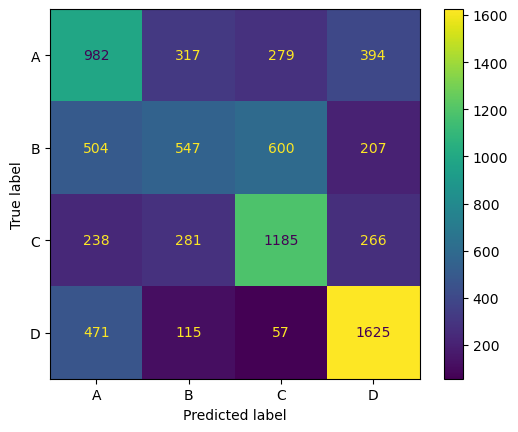

In [390]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(Y_train, label_encoder.inverse_transform(train_predections));

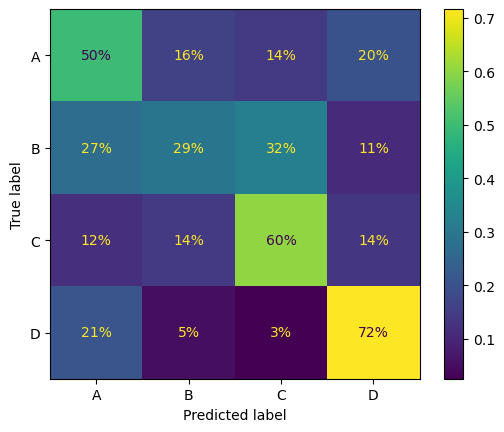

In [346]:
ConfusionMatrixDisplay.from_predictions(Y_train, label_encoder.inverse_transform(train_predections),
                                        normalize="true", values_format=".0%");

# Threshold tuning 

## The struggle in class B

In [362]:
Y_train_binaryLabel_B = (Y_train == 'B')

In [372]:
Y_train_binaryLabel_B

0       False
1       False
2        True
3        True
4       False
        ...  
8063    False
8064    False
8065    False
8066     True
8067     True
Name: Segmentation, Length: 8068, dtype: bool

In [374]:
binary_label_encoder = LabelEncoder()
Y_train_binaryLabel_B_encoded = binary_label_encoder.fit_transform(Y_train_binaryLabel_B)
Y_train_binaryLabel_B_encoded

array([0, 0, 1, ..., 0, 1, 1], dtype=int64)

In [378]:
B_probabilities = train_probabilities[:,1]
B_probabilities

array([0.01665157, 0.3824769 , 0.3614582 , ..., 0.13778165, 0.16015394,
       0.38736245], dtype=float32)

In [380]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(Y_train_binaryLabel_B_encoded, B_probabilities)

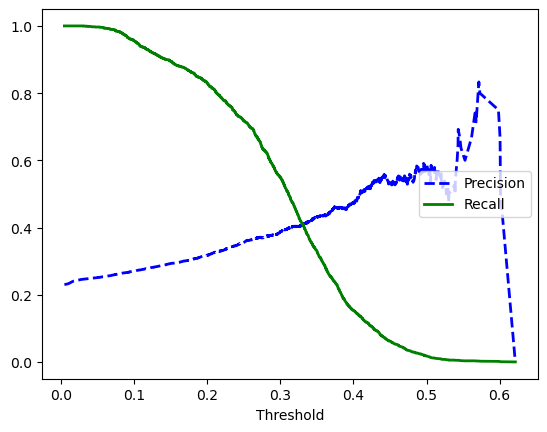

In [384]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Threshold")
plt.legend(loc="center right");

In [466]:
from custom_transformers import ThresholdWrapper

In [468]:
final_model_tuned_threshold = ThresholdWrapper(final_model , {1:0.35})

In [476]:

# 2. Establish the default argmax predictions
train_predections_tuned_threshold = np.argmax(train_probabilities, axis=1)

# 3. Apply  custom threshold for Class B (Index 1) to the out-of-fold data
custom_threshold = 0.35
meets_threshold = train_probabilities[:, 1] >= custom_threshold
train_predections_tuned_threshold[meets_threshold] = 1


train_predections_tuned_threshold = label_encoder.inverse_transform(unbiased_predictions_idx)



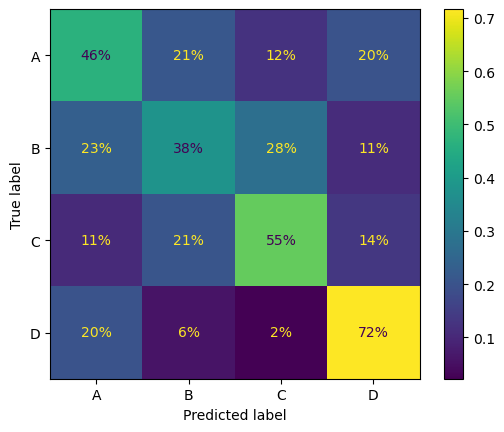

In [478]:
ConfusionMatrixDisplay.from_predictions(Y_train, train_predections_tuned_threshold,
                                        normalize="true", values_format=".0%");

In [480]:
precision = precision_score(average='macro', y_true= Y_train , y_pred=train_predections_tuned_threshold)
recall = recall_score(average='macro', y_true= Y_train , y_pred=train_predections_tuned_threshold)
f1 = f1_score(average='macro', y_true= Y_train , y_pred=train_predections_tuned_threshold)

precision,recall,f1

(0.5255032368898696, 0.5277758063311189, 0.525895877581102)